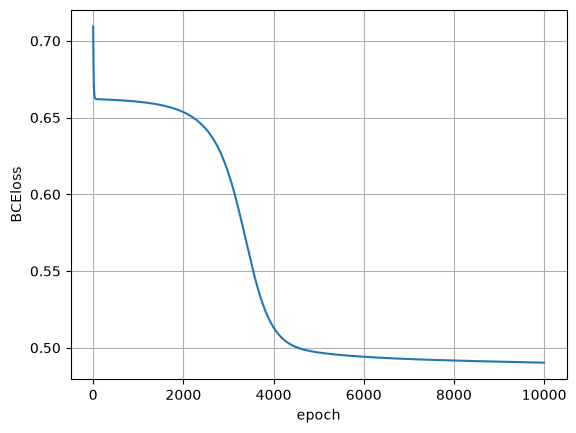

train loss: 0.4902816414833069
test loss: 0.44111815094947815


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
#注意，最后一个参数要用float32,因为一般的显卡不支持float64,而且float32就够用了
xy=np.loadtxt('diabetes.csv',delimiter=',',dtype=np.float32)
x_data=torch.from_numpy(xy[:400,:-1])#[行，列],:表示全部，st:en表示从st到en，左闭右开
y_data=torch.from_numpy(xy[:400,[-1]])#[-1]表示取这一列,得到N*1矩阵
x_test=torch.from_numpy(xy[400:,:-1])#[行，列],:表示全部，st:en表示从st到en，左闭右开
y_test=torch.from_numpy(xy[400:,[-1]])#[-1]表示取这一列,得到N*1矩阵
class Model(torch.nn.Module):
    def __init__(self):
        super().__init__()
        #多层网络，参数更多，学习能力更强
        self.linear1=torch.nn.Linear(8,6)
        self.linear2=torch.nn.Linear(6,4)
        self.linear3=torch.nn.Linear(4,1)
        self.sigmoid=torch.nn.Sigmoid()#激活函数，添加非线性因素
    def forward(self,x):
        x=self.sigmoid(self.linear1(x))
        x=self.sigmoid(self.linear2(x))
        x=self.sigmoid(self.linear3(x))
        return x
L=[]
model=Model()
criterion=torch.nn.BCELoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.1)
for epoch in range(10000):
    y_pred=model(x_data)
    loss=criterion(y_pred,y_data)
    L.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
plt.plot(L)
plt.xlabel('epoch')
plt.ylabel('BCEloss')
plt.grid()
plt.show()

print('train loss:',criterion(model(x_data),y_data).item())
print('test loss:',criterion(model(x_test),y_test).item())


